In [1]:
import sys
sys.path.append("/project/src")

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn import model_selection
from sklearn import preprocessing
from sklearn import impute

from itertools import product
import missingno as msno

from rsfmodel import RandomSurvivalForest
from coxmodel import CoxPH

from sklearn.model_selection import train_test_split
from sksurv.util import Surv
from lifelines import KaplanMeierFitter

In [3]:
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive')
    nacc_data_csv = "/content/drive/MyDrive/bachelor/nacc_data_2025.csv"
else:
    nacc_data_csv = "./data/nacc_data_2025.csv"

In [4]:
nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')

/tmp/ipykernel_12977/2070981678.py:1: DtypeWarning: Columns (4,8,10,21,25,27,28,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,138,149,190,193,195,201,203,205,207,209,211,215,217,219,221,223,225,227,229,231,233,235,237,239,241,245,370,372,374,405,418,425,465,545,576,601,636,652,669,672,689,700,706,758,760,762,763,769,792,805,813,814,815,816,826,848,851,854) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc_raw = pd.read_csv(nacc_data_csv, delimiter=',')


In [5]:
nacc_raw['TIME'].value_counts()

TIME
0.997     125
1.016      89
1.035      72
1.092      66
1.073      61
         ... 
17.881      1
5.829       1
11.984      1
5.719       1
17.547      1
Name: count, Length: 4633, dtype: int64

In [6]:
nacc_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17477 entries, 0 to 17476
Columns: 857 entries, NACCREFR to TIME
dtypes: float64(695), int64(29), object(133)
memory usage: 114.3+ MB


In [7]:
nacc_raw.describe()

,NACCREFR,SEX,HISPANIC,HISPOR,RACE,RACESEC,RACETER,PRIMLANG,EDUC,MARISTAT,...,NPPPRION,NPCPRION,NPPOTH1,NPCOTH1,NPPOTH2,NPCOTH2,NPPOTH3,NPCOTH3,EVENT_MCI,TIME
count,11634.000000,17477.000000,17405.000000,1292.000000,17391.000000,549.000000,114.000000,17230.000000,17396.000000,17338.000000,...,288.0,288.0,292.000000,292.000000,287.0,287.000000,287.0,287.000000,17477.000000,17477.000000
mean,1.364793,1.647422,0.076530,4.979102,1.776379,7.125683,4.745614,1.064771,15.900897,1.853443,...,2.0,2.0,1.873288,1.811644,2.0,1.940767,2.0,1.972125,0.232591,5.287227
std,0.481393,0.477786,0.265851,10.609484,4.877507,14.065042,10.778388,0.326417,2.957291,1.307986,...,0.0,0.0,0.333222,0.391668,0.0,0.236473,0.0,0.164901,0.422496,4.224563
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,2.0,2.0,1.000000,1.000000,2.0,1.000000,2.0,1.000000,0.000000,0.145000
25%,1.000000,1.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.000000,14.000000,1.000000,...,2.0,2.0,2.000000,2.000000,2.0,2.000000,2.0,2.000000,0.000000,1.990000
50%,1.000000,2.000000,0.000000,2.000000,1.000000,3.000000,3.000000,1.000000,16.000000,1.000000,...,2.0,2.0,2.000000,2.000000,2.0,2.000000,2.0,2.000000,0.000000,4.082000
75%,2.000000,2.000000,0.000000,5.000000,1.000000,3.000000,3.000000,1.000000,18.000000,2.000000,...,2.0,2.0,2.000000,2.000000,2.0,2.000000,2.0,2.000000,0.000000,7.379000
max,2.000000,2.000000,1.000000,50.000000,50.000000,50.000000,50.000000,6.000000,29.000000,6.000000,...,2.0,2.0,2.000000,2.000000,2.0,2.000000,2.0,2.000000,1.000000,19.220000


In [8]:
object_columns = nacc_raw.select_dtypes(include
  ='object').columns.tolist() 
len(object_columns)

133

In [9]:
nacc_raw[object_columns].isna().sum().sort_values(ascending=True).head(20).index

Index(['ADGCRND', 'DRUG3', 'DRUG4', 'NGDSGWAC', 'DRUG5', 'DRUG6', 'DRUG7',
       'NPIQINFX', 'DRUG8', 'ADGCEXR', 'NGDSWGAC', 'DRUG9', 'DRUG10',
       'NGDSEXAC', 'NACCOMX', 'NACCAMX', 'NACCAMSX', 'NACCFMX', 'NACCFMSX',
       'OTHCONDX'],
      dtype='object')

In [10]:
object_cols_df_missingness = nacc_raw[object_columns].isna().sum() / len(nacc_raw) * 100
object_cols_df_missingness.sort_values(ascending=True).head(20)

ADGCRND     25.948389
DRUG3       27.441781
DRUG4       37.781084
NGDSGWAC    40.310122
DRUG5       47.862906
DRUG6       57.652915
DRUG7       66.132631
NPIQINFX    72.020370
DRUG8       73.988671
ADGCEXR     74.829776
NGDSWGAC    76.414716
DRUG9       80.145334
DRUG10      85.123305
NGDSEXAC    85.638267
NACCOMX     86.668192
NACCAMX     86.816959
NACCAMSX    86.857012
NACCFMX     86.868456
NACCFMSX    86.879899
OTHCONDX    89.208674
dtype: float64

In [11]:
low_missing_values = nacc_raw[object_columns].isna().sum().sort_values(ascending=True).head(5).index
nacc_raw[low_missing_values].head(20)

,ADGCRND,DRUG3,DRUG4,NGDSGWAC,DRUG5
0,ADC 4,HYDROCHLOROTHIAZIDE,ASCORBIC ACID,NG00068,AMLODIPINE
1,ADC 7,MECLIZINE,QUAZEPAM,NG00071,CALCIUM-VITAMIN D
2,ADC 16,MECLIZINE,FLUTICASONE,NaN,CALCIUM-VITAMIN D
3,NaN,ASCORBIC ACID,LISINOPRIL,NaN,CHOLECALCIFEROL
4,NaN,NaN,NaN,NaN,NaN
5,ADC 17,PSYLLIUM,MULTIVITAMIN WITH MINERALS,NaN,ROSUVASTATIN
6,ADC 17d,NaN,NaN,NaN,NaN
7,NaN,AMLODIPINE,SIMVASTATIN,NaN,CALCIUM-VITAMIN D
8,ADC 17e,NaN,NaN,NaN,NaN
9,ADC 7,CALCIUM-VITAMIN D,MULTIVITAMIN,NG00071,NaN


In [12]:
nacc_raw.duplicated().sum()

np.int64(0)

In [13]:
nacc_raw.shape

(17477, 857)

In [14]:
# nacc_raw.rename(columns={"OUTCOME_EVENTMCI": "EVENT_MCI"}, inplace=True)

In [15]:
nacc_raw['TIME'].isna().sum(), nacc_raw['EVENT_MCI'].isna().sum()

(np.int64(0), np.int64(0))

In [16]:
nacc_raw['TIME'].isnull().sum(), nacc_raw['EVENT_MCI'].isnull().sum()

(np.int64(0), np.int64(0))

# Data cleanup

In [17]:
corrs_with_mci = (
    nacc_raw.select_dtypes(include='number')
    .corr()['EVENT_MCI']
    .abs()
    .sort_values(ascending=False)
)

In [18]:
corrs_with_mci

NACCMCII     1.000000
EVENT_MCI    1.000000
FTLDSUBT     1.000000
NACCNORM     0.797041
LOGIYR       0.505964
               ...   
NPTAUHAP          NaN
NPPPRION          NaN
NPCPRION          NaN
NPPOTH2           NaN
NPPOTH3           NaN
Name: EVENT_MCI, Length: 724, dtype: float64

In [19]:
leakage_vars = corrs_with_mci[corrs_with_mci == 1.0].index.tolist()
leakage_vars.remove('EVENT_MCI')
leakage_vars

['NACCMCII', 'FTLDSUBT']

In [20]:
corrs_with_mci['NACCADMD']

np.float64(0.08222767872569063)

In [21]:
corrs_with_mci['NACCETPR']

np.float64(0.179279344975999)

Delete variables that can replace the target variable

In [22]:
nacc_raw.drop(columns=['NACCACTV', 'NACCADMD', 'NACCALZD', 'NACCALZP', 'PROBAD', 'PROBADIF', 'POSSAD', 'POSSADIF'], inplace=True)

In [23]:
nacc_raw.drop(columns=['NACCMCII', 'NACCNORM', 'COGSTAT', "NACCETPR"], inplace=True)

In [24]:
nacc_raw.drop(columns=['COGOTH3F'], inplace=True)

## Analyse missing values

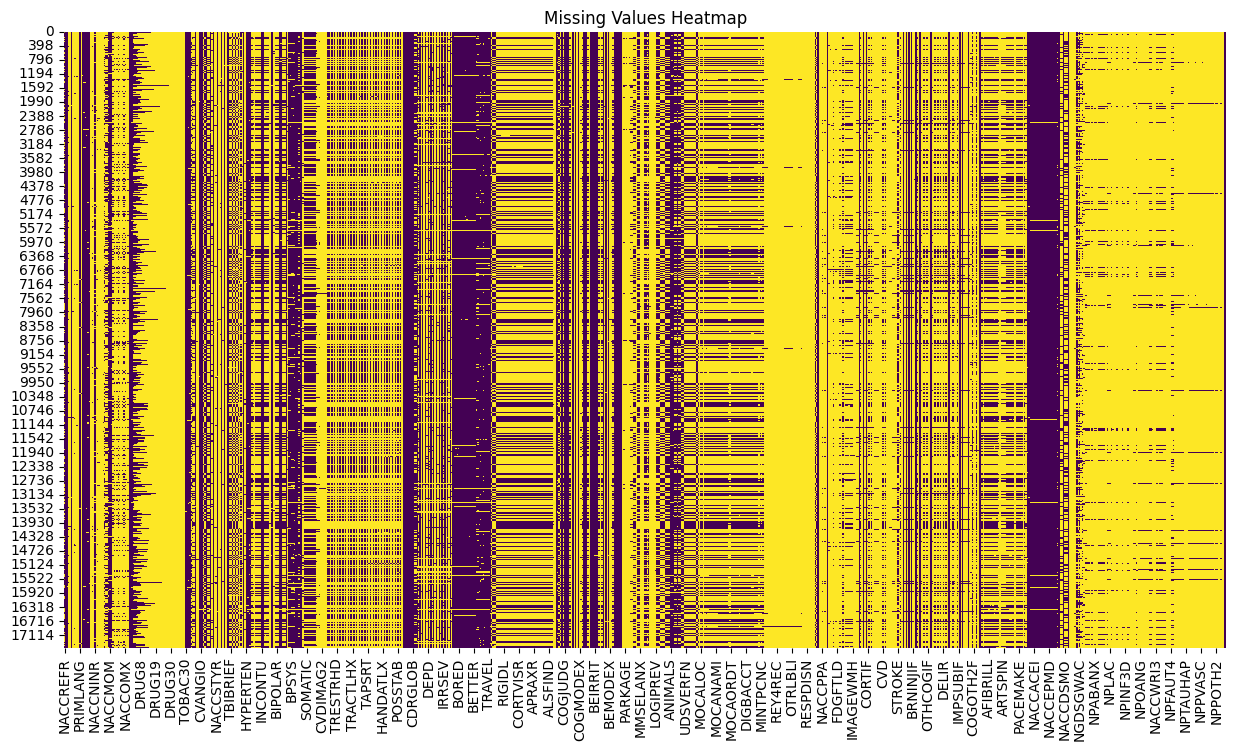

In [25]:
plt.figure(figsize=(15, 8))
sns.heatmap(nacc_raw.isna(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [26]:
missing_percantage_per_column = nacc_raw.isna().sum() / len(nacc_raw) * 100
missing_percantage_per_column

NACCREFR     33.432511
SEX           0.000000
HISPANIC      0.411970
HISPOR       92.607427
HISPORX      99.622361
               ...    
NPPOTH3      98.357842
NPCOTH3      98.357842
NPOTH3X      99.942782
EVENT_MCI     0.000000
TIME          0.000000
Length: 844, dtype: float64

In [27]:
LOW_MISSINGNESS_THRESHOLD = 20
HIGH_MISSINGNESS_THRESHOLD = 80

In [28]:
# Create datasets based on missing value percentages
low_missing = missing_percantage_per_column[missing_percantage_per_column < LOW_MISSINGNESS_THRESHOLD].index.tolist()
medium_missing = missing_percantage_per_column[(missing_percantage_per_column >= LOW_MISSINGNESS_THRESHOLD) & (missing_percantage_per_column < HIGH_MISSINGNESS_THRESHOLD)].index.tolist()
high_missing = missing_percantage_per_column[missing_percantage_per_column >= HIGH_MISSINGNESS_THRESHOLD].index.tolist()

# Create separate dataframes for each category
nacc_low_missing = nacc_raw[low_missing]
nacc_medium_missing = nacc_raw[medium_missing]
nacc_high_missing = nacc_raw[high_missing]

print(f"Low missing (<{LOW_MISSINGNESS_THRESHOLD}%): {len(low_missing)} columns")
print(f"Medium missing ({LOW_MISSINGNESS_THRESHOLD}-{HIGH_MISSINGNESS_THRESHOLD}%): {len(medium_missing)} columns")
print(f"High missing (>{HIGH_MISSINGNESS_THRESHOLD}%): {len(high_missing)} columns")

Low missing (<20%): 181 columns
Medium missing (20-80%): 273 columns
High missing (>80%): 390 columns


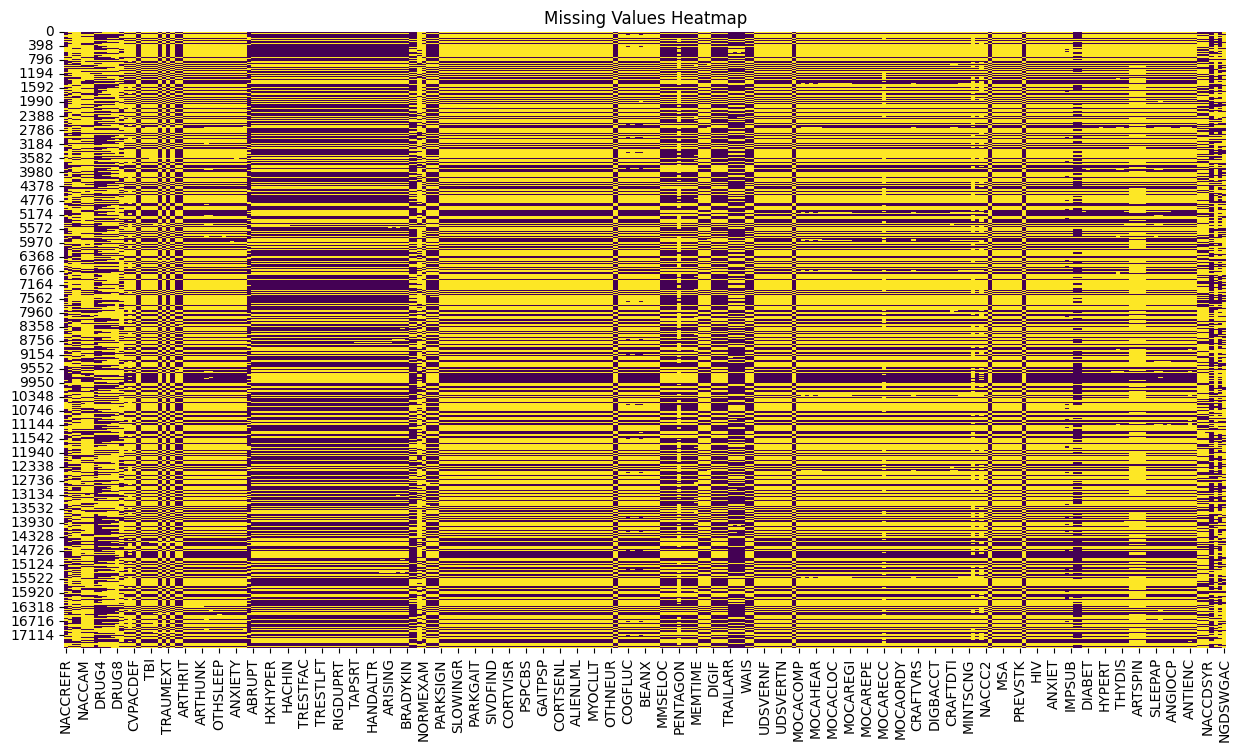

In [29]:
plt.figure(figsize=(15, 8))
sns.heatmap(nacc_medium_missing.isna(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [30]:
len(nacc_medium_missing.columns)

273

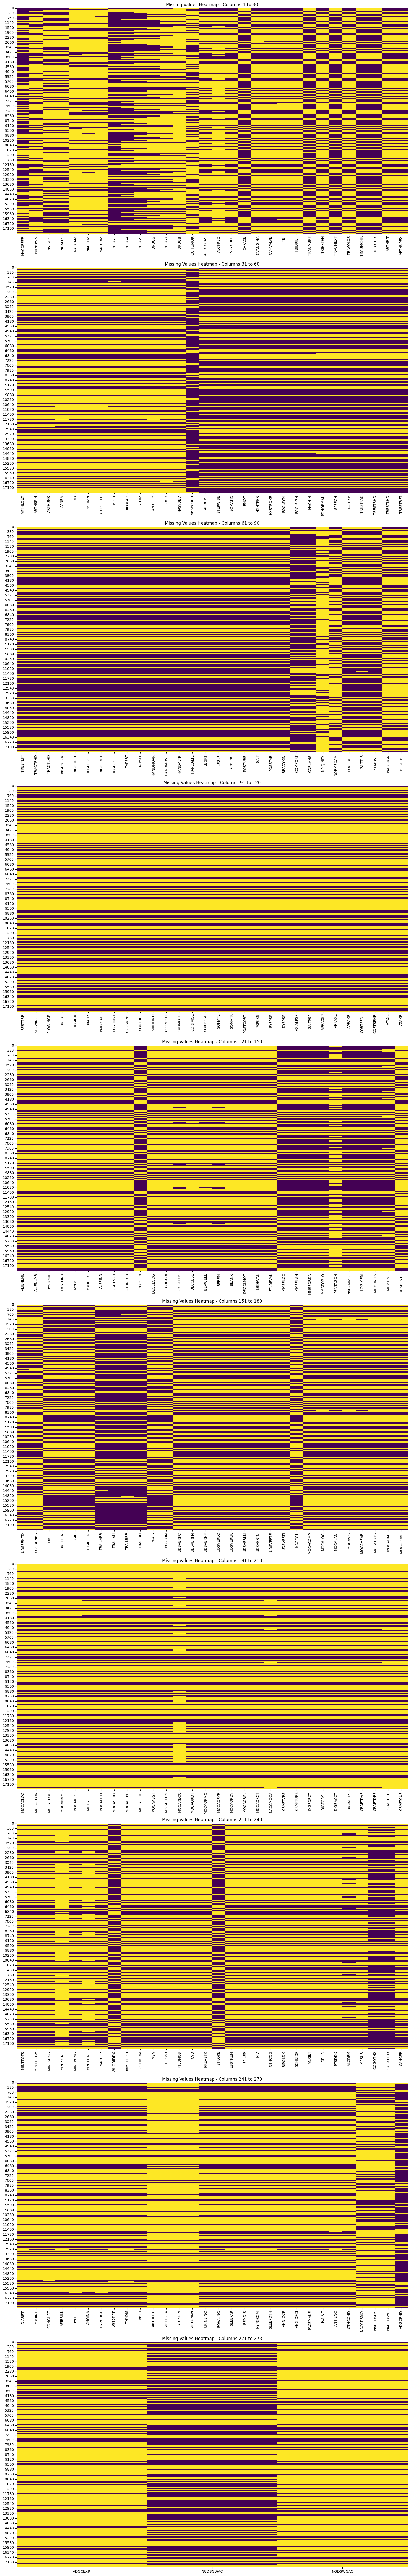

In [31]:
columns_per_plot = 30
num_plots = (len(nacc_medium_missing.columns) + columns_per_plot - 1) // columns_per_plot

fig, axes = plt.subplots(num_plots, 1, figsize=(16, 10 * num_plots))

for i, ax in enumerate(axes):
  start_idx = i * columns_per_plot
  end_idx = min(start_idx + columns_per_plot, len(nacc_medium_missing.columns))
  
  subset = nacc_medium_missing.iloc[:, start_idx:end_idx]
  
  sns.heatmap(subset.isna(), cbar=False, cmap='viridis', ax=ax)
  ax.set_title(f'Missing Values Heatmap - Columns {start_idx + 1} to {end_idx}')

plt.tight_layout()
plt.show()

In [32]:
def filter_columns_by_missing_pattern(df, reference_col='HIV'):
    if reference_col not in df.columns:
        raise KeyError(f"Column '{reference_col}' not found in dataframe.")

    reference_mask = df[reference_col].isna().to_numpy()

    forward_columns = []
    opposite_columns = []

    for col in df.columns:
        col_mask = df[col].isna().to_numpy()

        if np.array_equal(col_mask, reference_mask):
            forward_columns.append(col)
        elif np.array_equal(col_mask, ~reference_mask):
            opposite_columns.append(col)

    kept_columns = forward_columns + opposite_columns
    dropped_columns = [col for col in df.columns if col not in kept_columns]
    filtered_df = df[kept_columns].copy()

    return filtered_df, forward_columns, opposite_columns, dropped_columns

nacc_pattern_filtered, forward_cols, opposite_cols, pattern_dropped_cols = filter_columns_by_missing_pattern(
    nacc_medium_missing,
)

print(f'Forward-pattern columns: {len(forward_cols)}')
print(f'Opposite-pattern columns: {len(opposite_cols)}')
print(f'Pattern-dropped columns: {len(pattern_dropped_cols)}')


Forward-pattern columns: 23
Opposite-pattern columns: 3
Pattern-dropped columns: 247


In [33]:
nacc_pattern_filtered.columns.tolist()

['DECCLCOG',
 'DECCLBE',
 'DECCLMOT',
 'LBDEVAL',
 'FTLDEVAL',
 'DXMETHOD',
 'OTHBIOM',
 'MSA',
 'FTLDMO',
 'FTLDNOS',
 'CVD',
 'PREVSTK',
 'ESSTREM',
 'EPILEP',
 'HIV',
 'OTHCOG',
 'BIPOLDX',
 'SCHIZOP',
 'ANXIET',
 'DELIR',
 'PTSDDX',
 'IMPSUB',
 'OTHCOND',
 'DECCLIN',
 'WHODIDDX',
 'STROKE']

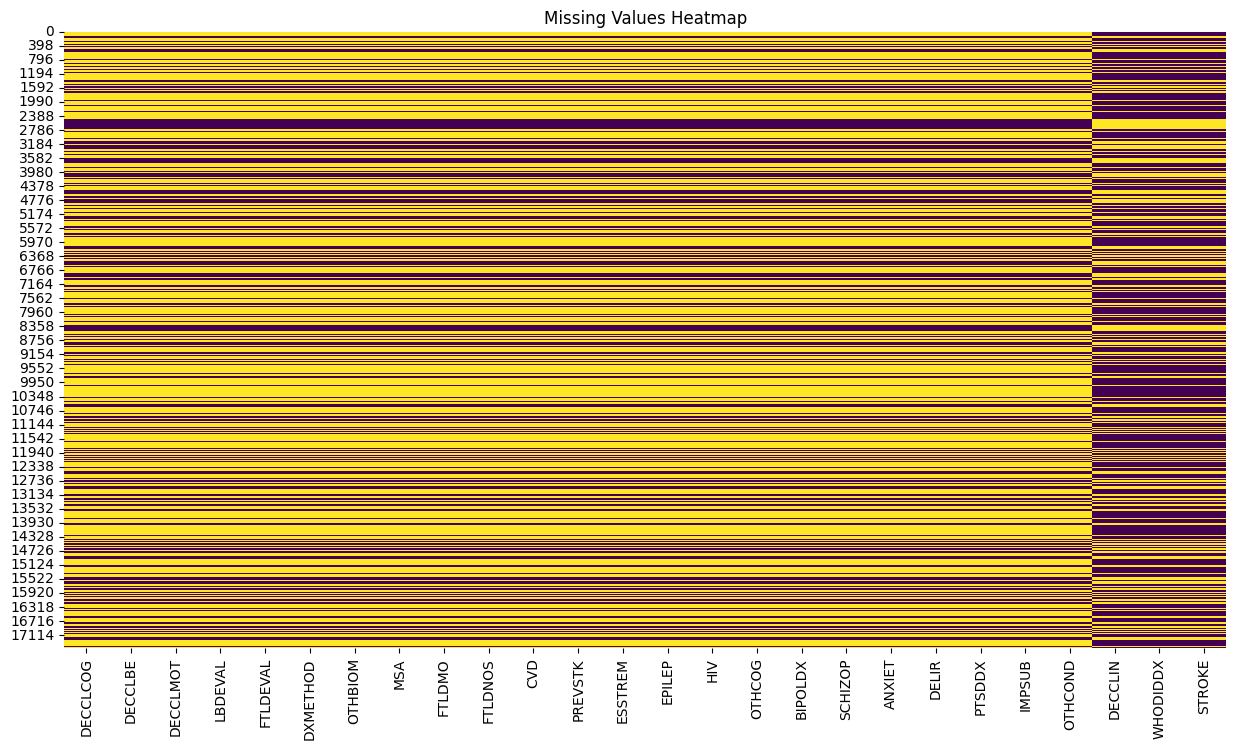

In [34]:
plt.figure(figsize=(15, 8))
sns.heatmap(nacc_pattern_filtered.isna(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [35]:
columns_to_proceed = nacc_pattern_filtered.columns.tolist() + low_missing
nacc_missing_pattern_filtered = nacc_raw[columns_to_proceed].copy()
print(f'Final kept columns: {nacc_missing_pattern_filtered.shape[1]}')

Final kept columns: 207


In [36]:
object_columns = nacc_missing_pattern_filtered.select_dtypes(include
  ='object').columns.tolist() 
len(object_columns)
object_columns

[]

In [37]:
low_missing_in_filtered = [c for c in low_missing if c in nacc_missing_pattern_filtered.columns]

print(f"V3 V2 rows before complete-case filtering: {nacc_missing_pattern_filtered.shape[0]}")

nacc_missing_free_v2_v3 = nacc_missing_pattern_filtered.dropna(
    subset=low_missing_in_filtered
).copy()

nacc_missing_free_v2_v3['group_missing_indicator'] = np.where(
    nacc_missing_free_v2_v3['HIV'].isna(), 1, 0
)

print(f'Low-missing columns used for complete-case filtering: {nacc_missing_free_v2_v3.shape[0]}')

nacc_missing_free_v3 = nacc_missing_pattern_filtered.copy()
nacc_missing_free_v3.drop(opposite_cols, axis=1, inplace=True)
nacc_missing_free_v3.dropna(inplace=True)

nacc_missing_free_v2 = nacc_missing_pattern_filtered.copy()
nacc_missing_free_v2.drop(forward_cols, axis=1, inplace=True)
nacc_missing_free_v2.dropna(inplace=True)

V3 V2 rows before complete-case filtering: 17477
Low-missing columns used for complete-case filtering: 7739


In [38]:
nacc_missing_free_v3.shape, nacc_missing_free_v2.shape

((2883, 204), (4856, 184))

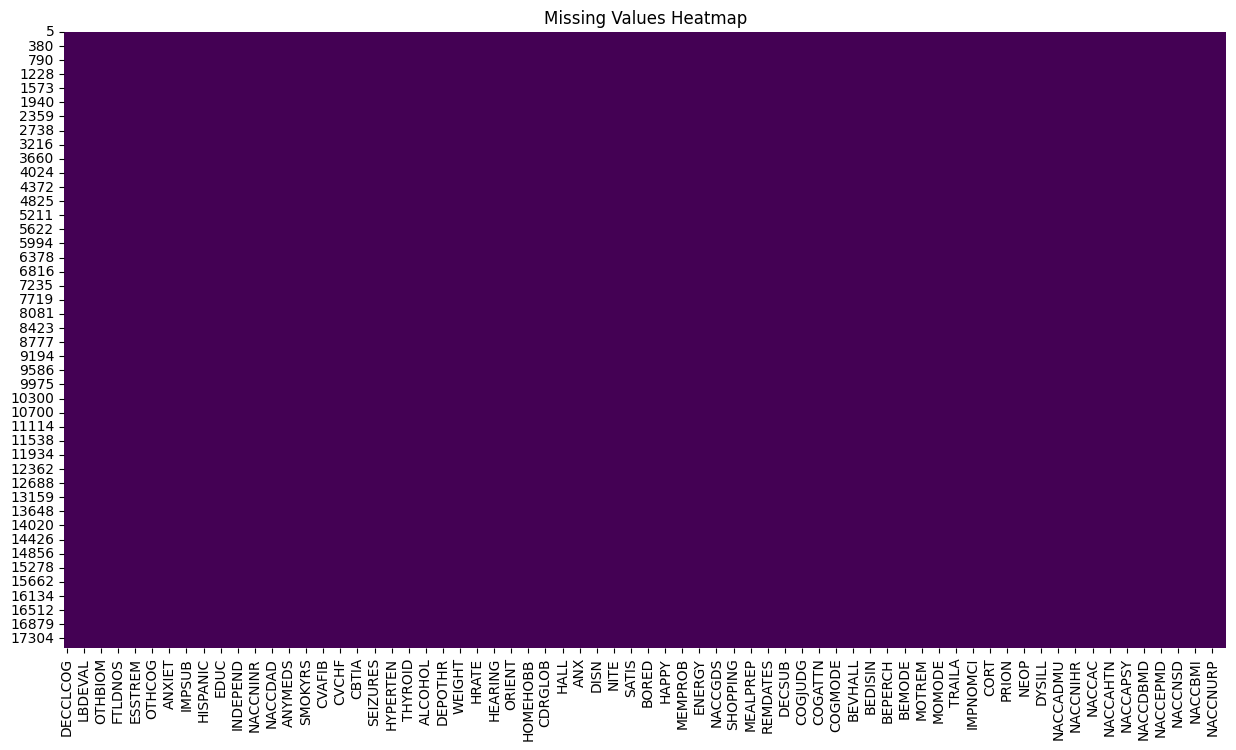

In [39]:
plt.figure(figsize=(15, 8))
sns.heatmap(nacc_missing_free_v3.isna(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

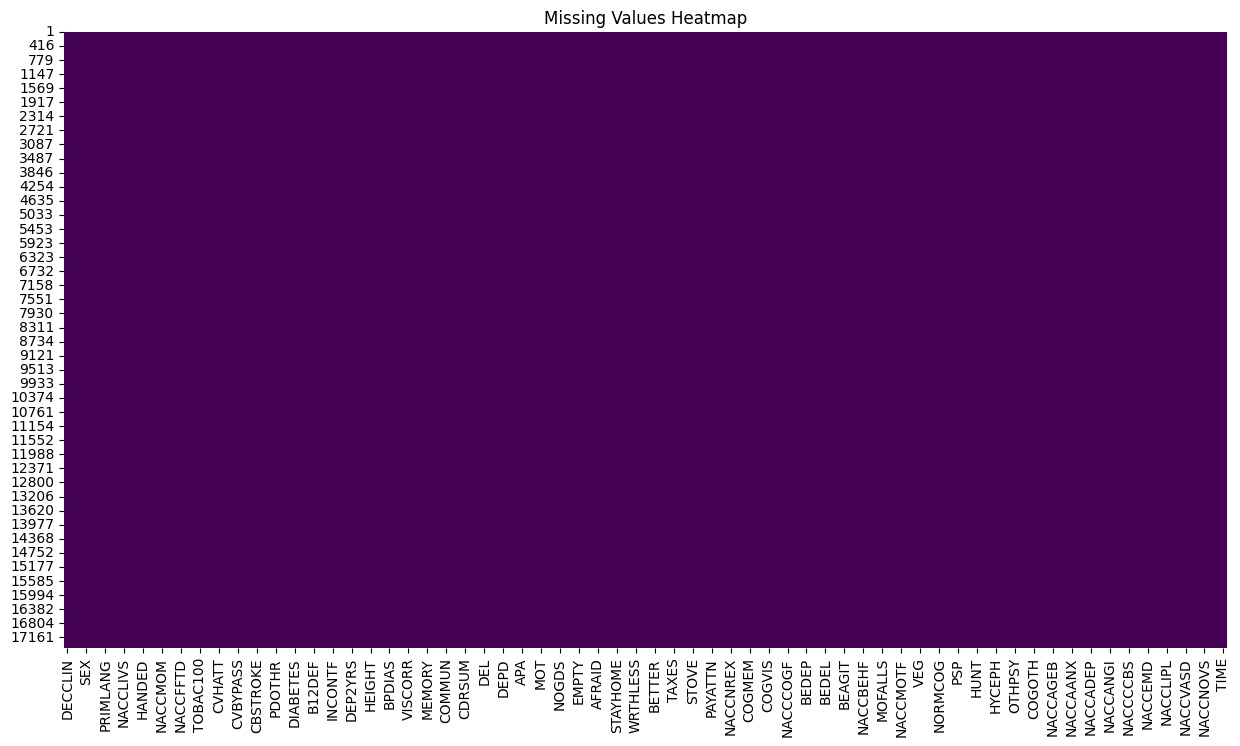

In [40]:
plt.figure(figsize=(15, 8))
sns.heatmap(nacc_missing_free_v2.isna(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [41]:
nacc_missing_free_v2_v3.shape

(7739, 208)

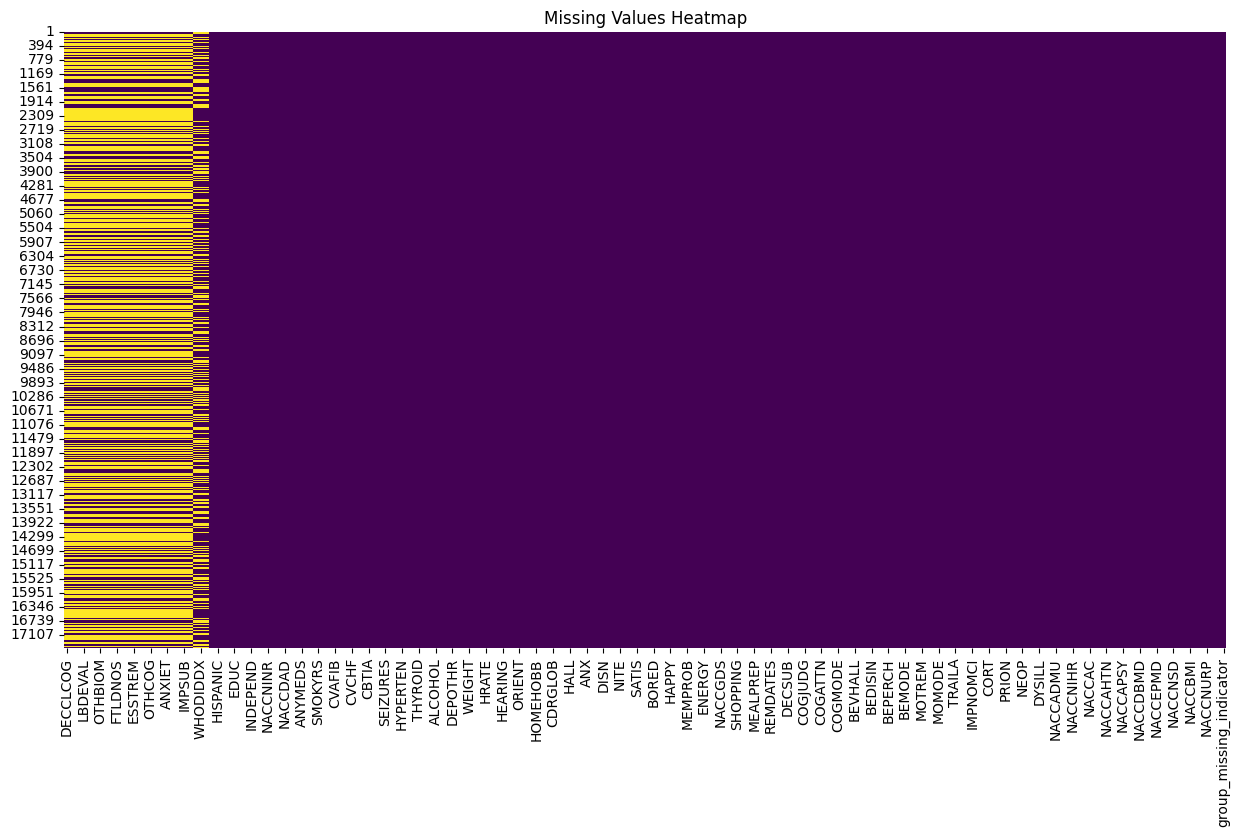

In [42]:
plt.figure(figsize=(15, 8))
sns.heatmap(nacc_missing_free_v2_v3.isna(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [43]:
corrs_with_mci_filtered = (
    nacc_missing_free_v2_v3.select_dtypes(include='number')
    .corr()['EVENT_MCI']
    .abs()
    .sort_values(ascending=False)
)
corrs_with_mci_filtered['CDRGLOB']

np.float64(0.15058150149314545)

In [44]:
pd.crosstab(nacc_missing_free_v2_v3['CDRGLOB'],  
  nacc_missing_free_v2_v3['EVENT_MCI'],            
  normalize='index')

EVENT_MCI,0,1
CDRGLOB,,
0.0,0.807361,0.192639
0.5,0.603338,0.396662
1.0,0.500000,0.500000


# Columns cleaning

After analysis of the documentation it was found out, that all the categorical variables have up to 10 variables. That mean, that we will set the categorical threshold to 10, and all the columns with values up to 10 will be considered as categorical

In [45]:
NOT_COLLECTED_PLACEHOLDER_VALUE = -99.0

In [46]:
def clean_columns(df):
    df_clean = df.copy()
    
    all_categorical_cols = []
    all_continuous_cols = []
    categorical_cols_by_unique_count = {i: [] for i in range(2, 11)}
    for col in df_clean.columns:
        if col == 'EVENT_MCI':
            continue
        
        n_unique = df_clean[col].nunique(dropna=True)
        if n_unique == 1:
            df_clean.drop(columns=[col], inplace=True)
            continue
        if 2 <= n_unique <= 10:
            all_categorical_cols.append(col)
            categorical_cols_by_unique_count[n_unique].append(col)
            df_clean[col] = df_clean[col].fillna(NOT_COLLECTED_PLACEHOLDER_VALUE)
            continue
        # impute continuous columns with mean
        if col == 'TIME':
            continue
        mean_value = df_clean[col].mean(numeric_only=True)
        df_clean[col] = df_clean[col].fillna(mean_value)
        all_continuous_cols.append(col)

    columns_with_low_variance = []

    for col in all_categorical_cols:
      # check 1: overall imbalance
      col_value_proportions = df_clean[col].value_counts(normalize=True, dropna=True)
      if col_value_proportions.iloc[0] > 0.99:
          print(f"Column '{col}' is overall imbalanced ({col_value_proportions.iloc[0]:.2%})")
          columns_with_low_variance.append(col)
          continue  # no need to check further

      # check 2: separation within event groups (the actual cause of your problem)
      events = df_clean["EVENT_MCI"].astype(bool)
      for group_name, mask in [("events", events), ("non-events", ~events)]:
          group_proportions = df_clean.loc[mask, col].value_counts(normalize=True, dropna=True)
          if group_proportions.iloc[0] > 0.95:
              print(f"Column '{col}' is imbalanced within {group_name} ({group_proportions.iloc[0]:.2%})")
              columns_with_low_variance.append(col)
              break

    for col in all_continuous_cols:
        col_var = df_clean[col].var(numeric_only=True)
        if col_var == 0.0000:
          df_clean.drop(columns=[col], inplace=True)
          continue
        if col_var < 0.01:
          print(f"Column '{col}' has very low variance ({col_var:.6f}); consider to drop it.")
          columns_with_low_variance.append(col)

    return df_clean, all_categorical_cols, all_continuous_cols, categorical_cols_by_unique_count, columns_with_low_variance

In [47]:
nacc_clean, nacc_categorical_columns, nacc_continuous_columns, _, columns_with_low_variance = clean_columns(nacc_missing_free_v2_v3)

Column 'HISPANIC' is imbalanced within events (95.22%)
Column 'PRIMLANG' is imbalanced within events (97.52%)
Column 'INDEPEND' is imbalanced within events (97.58%)
Column 'NACCFADM' is overall imbalanced (99.26%)
Column 'NACCFFTD' is imbalanced within events (99.33%)
Column 'TOBAC30' is imbalanced within events (97.09%)
Column 'CVHATT' is imbalanced within events (95.15%)
Column 'CVANGIO' is imbalanced within non-events (96.09%)
Column 'CVBYPASS' is imbalanced within events (95.82%)
Column 'CVCHF' is imbalanced within events (98.55%)
Column 'CBSTROKE' is imbalanced within events (97.33%)
Column 'CBTIA' is imbalanced within events (95.64%)
Column 'PD' is imbalanced within events (98.12%)
Column 'PDOTHR' is overall imbalanced (99.78%)
Column 'SEIZURES' is imbalanced within events (98.06%)
Column 'B12DEF' is imbalanced within non-events (95.61%)
Column 'INCONTF' is imbalanced within events (97.21%)
Column 'ALCOHOL' is imbalanced within events (97.03%)
Column 'ABUSOTHR' is imbalanced with

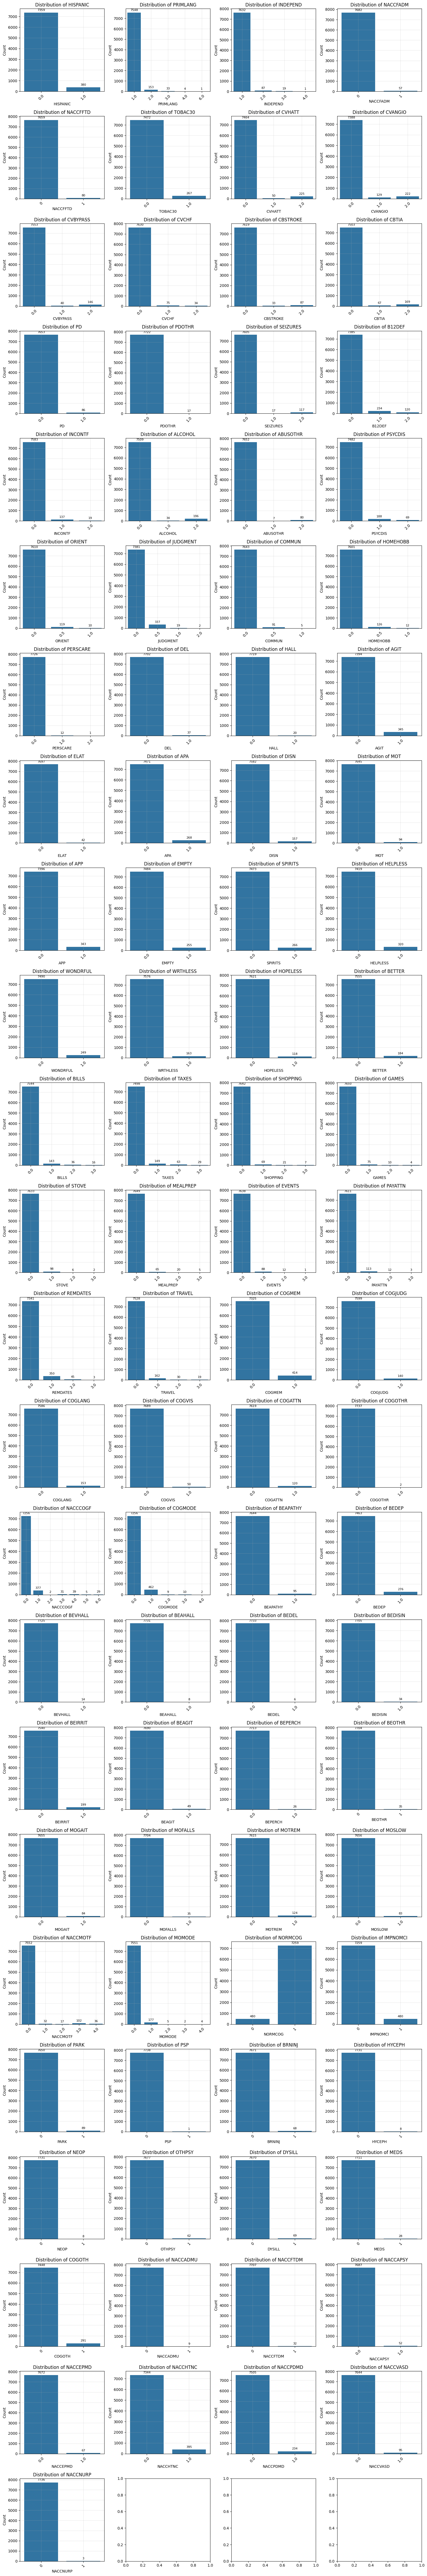

In [48]:
n_cols = 4
n_rows = (len(columns_with_low_variance) + n_cols - 1) // n_cols  
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(columns_with_low_variance):
    ax = axes[i]
    if col in nacc_categorical_columns:
        bars = sns.countplot(x=nacc_clean[col], ax=ax)
        for bar in ax.containers:
            ax.bar_label(bar, padding=3, fontsize=8)
    else:
        sns.histplot(nacc_clean[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [49]:
columns_with_low_variance

['HISPANIC',
 'PRIMLANG',
 'INDEPEND',
 'NACCFADM',
 'NACCFFTD',
 'TOBAC30',
 'CVHATT',
 'CVANGIO',
 'CVBYPASS',
 'CVCHF',
 'CBSTROKE',
 'CBTIA',
 'PD',
 'PDOTHR',
 'SEIZURES',
 'B12DEF',
 'INCONTF',
 'ALCOHOL',
 'ABUSOTHR',
 'PSYCDIS',
 'ORIENT',
 'JUDGMENT',
 'COMMUN',
 'HOMEHOBB',
 'PERSCARE',
 'DEL',
 'HALL',
 'AGIT',
 'ELAT',
 'APA',
 'DISN',
 'MOT',
 'APP',
 'EMPTY',
 'SPIRITS',
 'HELPLESS',
 'WONDRFUL',
 'WRTHLESS',
 'HOPELESS',
 'BETTER',
 'BILLS',
 'TAXES',
 'SHOPPING',
 'GAMES',
 'STOVE',
 'MEALPREP',
 'EVENTS',
 'PAYATTN',
 'REMDATES',
 'TRAVEL',
 'COGMEM',
 'COGJUDG',
 'COGLANG',
 'COGVIS',
 'COGATTN',
 'COGOTHR',
 'NACCCOGF',
 'COGMODE',
 'BEAPATHY',
 'BEDEP',
 'BEVHALL',
 'BEAHALL',
 'BEDEL',
 'BEDISIN',
 'BEIRRIT',
 'BEAGIT',
 'BEPERCH',
 'BEOTHR',
 'MOGAIT',
 'MOFALLS',
 'MOTREM',
 'MOSLOW',
 'NACCMOTF',
 'MOMODE',
 'NORMCOG',
 'IMPNOMCI',
 'PARK',
 'PSP',
 'BRNINJ',
 'HYCEPH',
 'NEOP',
 'OTHPSY',
 'DYSILL',
 'MEDS',
 'COGOTH',
 'NACCADMU',
 'NACCFTDM',
 'NACCAPSY',
 'N

In [50]:
keep_columns = ["NACCFADM", "ELAT", "GAMES", "MOGAIT", "MOSLOW", "BRNINJ", "OTHPSY"]

After analysis of all the columns with low variance I have come to conclusion, that non of the columns have potential value for the prediction of the target variable. Moreover, many of them represented the directly connected variables, that represent the MCI itself and cannot be included in the final dataset

In [51]:
nacc_clean.drop(columns=[col for col in columns_with_low_variance if col not in keep_columns], inplace=True)
nacc_clean.shape

(7739, 115)

# Censorship

In [52]:
def calculate_censorship_rate(df):
  censored_data = df[df['EVENT_MCI'] == 0]
  return censored_data.shape[0] / df.shape[0]

In [53]:
calculate_censorship_rate(nacc_clean)

0.7866649437911875

In [54]:
nacc_clean.shape

(7739, 115)

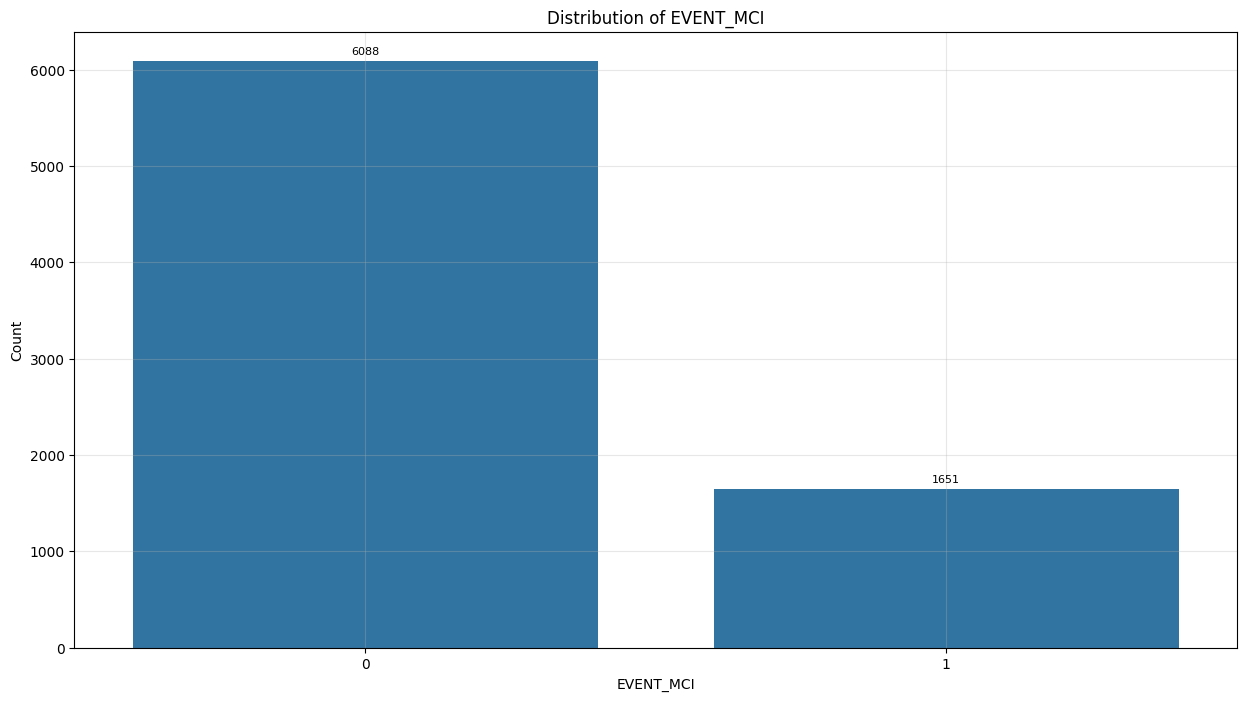

In [55]:
plt.figure(figsize=(15, 8))
bars = sns.barplot(x=nacc_clean['EVENT_MCI'].value_counts().index, y=nacc_clean['EVENT_MCI'].value_counts().values)
for bar in bars.containers:
    ax = bars.axes
    ax.bar_label(bar, padding=3, fontsize=8)
plt.title('Distribution of EVENT_MCI')
plt.xlabel('EVENT_MCI')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

In [56]:
nacc_clean['EVENT_MCI'].value_counts() / nacc_clean.shape[0]

EVENT_MCI
0    0.786665
1    0.213335
Name: count, dtype: float64

In [57]:
optimal_features_values = nacc_clean[nacc_clean['EVENT_MCI'] == 1].shape[0] / 10
optimal_features_values

165.1

Following the "Event per variabel" (EVP) rule, the optimal features subset size is equal to 95 variabels for the stable cox modelling

# Encode categorical values

In [58]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')

In [59]:
collapse_threshold = 0.2

In [60]:
def collapse_rare_categories(df, categorical_cols, threshold=0.05):
    df_result = df.copy()
    for col in categorical_cols:
        if col not in df_result.columns:
            continue
      
        value_counts = df_result[col][df_result[col] != NOT_COLLECTED_PLACEHOLDER_VALUE].value_counts(normalize=True)
        rare_categories = value_counts[value_counts < threshold].index
        
        if len(rare_categories) > 0:
            rare_categories_str = ', '.join(map(str, rare_categories))
            df_result[col] = df_result[col].replace(rare_categories, f'{col}_{rare_categories_str}')
            print(f"Column '{col}': collapsed {len(rare_categories)} categories -> {df_result[col].nunique()} unique values")
    
    return df_result

nacc_categorical_columns = [col for col in nacc_categorical_columns if col in nacc_clean.columns]
# We do not want to event mci to be one-hot encoded, as it is our target variable, and we do not want to time to be one-hot encoded, as it is our time variable
protected_cols = ['EVENT_MCI']
encode_cols = [col for col in nacc_categorical_columns if col not in protected_cols]

nacc_prepared = nacc_clean.copy()
nacc_prepared = collapse_rare_categories(nacc_prepared, nacc_categorical_columns, threshold=0.05)

nacc_prepared[nacc_continuous_columns] = pt.fit_transform(nacc_prepared[nacc_continuous_columns])

# Since we are doing feature selection for the further EDA
# We need to store the mapping for each encoded variable to original clumns names
dummy_mapping = {}
for col in encode_cols:
    unique_values = nacc_prepared[col].unique()
    for value in unique_values:
        dummy_name = f"{col}_{value}"
        dummy_mapping[dummy_name] = col

nacc_prepared_dummies = pd.get_dummies(nacc_prepared, columns=encode_cols)
# get_dummies created "missing indicator" column for each categorical variable
# We need to remove all of them, since, they have structural missingness
# We can encode missing indicator with only one column
cols_to_drop = [col for col in nacc_prepared_dummies.columns if col.endswith(str(NOT_COLLECTED_PLACEHOLDER_VALUE))]
nacc_prepared_dummies.drop(columns=cols_to_drop, inplace=True)
nacc_prepared_dummies.head(20)

Column 'DECCLMOT': collapsed 1 categories -> 3 unique values
Column 'LBDEVAL': collapsed 1 categories -> 3 unique values
Column 'FTLDEVAL': collapsed 1 categories -> 3 unique values
Column 'OTHBIOM': collapsed 1 categories -> 3 unique values
Column 'FTLDMO': collapsed 1 categories -> 3 unique values
Column 'FTLDNOS': collapsed 1 categories -> 3 unique values
Column 'CVD': collapsed 1 categories -> 3 unique values
Column 'PREVSTK': collapsed 1 categories -> 3 unique values
Column 'ESSTREM': collapsed 1 categories -> 3 unique values
Column 'EPILEP': collapsed 1 categories -> 3 unique values
Column 'OTHCOG': collapsed 1 categories -> 3 unique values
Column 'BIPOLDX': collapsed 1 categories -> 3 unique values
Column 'SCHIZOP': collapsed 1 categories -> 3 unique values
Column 'ANXIET': collapsed 1 categories -> 3 unique values
Column 'DELIR': collapsed 1 categories -> 3 unique values
Column 'PTSDDX': collapsed 1 categories -> 3 unique values
Column 'IMPSUB': collapsed 1 categories -> 3 uniq

,EDUC,SMOKYRS,HEIGHT,WEIGHT,BPSYS,BPDIAS,HRATE,CDRSUM,NACCGDS,NACCBEHF,...,NACCLIPL_0.0,NACCLIPL_1.0,NACCNSD_0.0,NACCNSD_1.0,NACCDIED_0,NACCDIED_1,NACCNOVS_0,NACCNOVS_1,group_missing_indicator_0,group_missing_indicator_1
1,0.691433,1.528033,-1.416714,-0.750256,1.211552,-0.593010,1.871669,2.642961,-0.968362,-0.271419,...,True,False,False,True,False,True,False,True,False,True
4,-0.094395,1.407738,0.898874,0.215128,-0.052453,-0.492990,0.134194,2.642961,-0.968362,3.684872,...,True,False,True,False,True,False,False,True,False,True
5,1.534531,0.811574,0.653303,0.753354,0.503125,-0.593010,-0.161348,2.642961,1.063098,-0.271419,...,False,True,False,True,True,False,True,False,True,False
6,1.534531,-0.813364,0.898874,0.080301,-1.182345,-0.997899,0.596478,-0.377880,-0.968362,-0.271419,...,True,False,True,False,True,False,True,False,True,False
7,-0.820787,-0.813364,-1.114836,-0.031369,0.556265,-1.306893,0.229558,-0.377880,0.522116,-0.271419,...,False,True,False,True,True,False,True,False,False,True
10,-0.820787,-0.813364,-1.055506,-1.150319,0.661311,0.862201,-0.913062,-0.377880,-0.968362,-0.271419,...,True,False,False,True,True,False,True,False,False,True
12,1.105947,-0.813364,0.477540,-0.088540,0.503125,0.767976,-0.913062,-0.377880,1.063098,-0.271419,...,True,False,True,False,True,False,False,True,True,False
15,-0.094395,1.423834,-0.678038,-1.596961,-1.975981,-1.620775,0.037288,2.642961,1.063098,3.684872,...,True,False,True,False,True,False,False,True,True,False
17,0.691433,0.959245,-0.259364,0.107680,-1.531955,-1.410962,-1.028472,-0.377880,-0.968362,-0.271419,...,False,True,False,True,True,False,True,False,False,True
27,0.691433,-0.813364,0.528089,-1.306856,-0.980717,-1.100373,-0.366764,-0.377880,0.522116,-0.271419,...,True,False,True,False,True,False,True,False,True,False


# KM curve

In [61]:
def draw_km_curve(df, time_col='TIME', event_col='EVENT_MCI'):
    kmf = KaplanMeierFitter()
    kmf.fit(durations=df[time_col], event_observed=df[event_col])
    
    plt.figure(figsize=(10, 6))
    kmf.plot_survival_function()
    plt.title('Kaplan-Meier Survival Curve')
    plt.xlabel('Time')
    plt.ylabel('Survival Probability')
    plt.grid()
    plt.show()

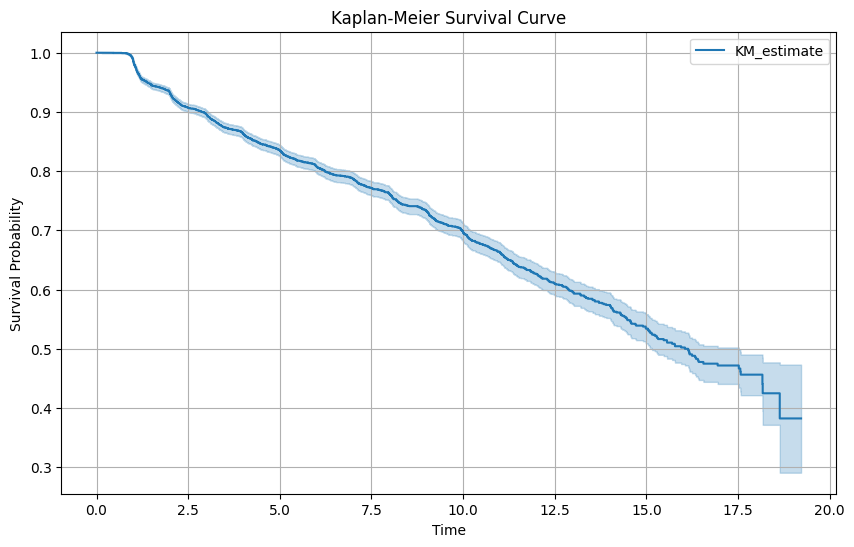

In [62]:
draw_km_curve(nacc_prepared_dummies)

# Feature selection for the further analysis

In [63]:
nacc_final_eda = nacc_prepared_dummies.copy()

In [64]:
common_features = ["RACE", 'EDUC', 'SEX', 'NACCGDS', "SMOKYRS", "ALCOHOL", "NACCBMI", "NACCREFR", "PRIMLANG", 'CSFTAU', "NACCDAD", "NACCMOM"]

## Select features

In [65]:
N_IMPORTANT_FEATURES = 30

### RSF VIMP

In [ ]:
def rsf_vimp(x_data, y_data, n_estimators=500):
    rsf = RandomSurvivalForest(
        num_trees     = n_estimators,
        min_node_size = 20,
        mtry          = int(np.sqrt(x_data.shape[1])),
        importance    = "permutation"
    )
    rsf.fit(x_data, y_data)
    vimp_importance = rsf.get_importance()
    return vimp_importance

: 

In [67]:
vimp_top_features = rsf_vimp(
  nacc_final_eda.drop(columns=['TIME', 'EVENT_MCI']),
  Surv.from_dataframe('EVENT_MCI', 'TIME', nacc_final_eda)
)
vimp_top_features = vimp_top_features.head(N_IMPORTANT_FEATURES)

vimp_top_features_decoded = set([dummy_mapping.get(feature, feature) for feature in vimp_top_features.index])
vimp_top_features_decoded

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  




Running Random Survival Forest with parameters: num_trees=500, min_node_size=20, mtry=15, splitrule='C', importance='permutation', compute_weights=True, replace=True, sample_fraction=1.0
Growing trees.. Progress: 1%. Estimated remaining time: 42 minutes, 32 seconds.
Growing trees.. Progress: 3%. Estimated remaining time: 34 minutes, 5 seconds.
Growing trees.. Progress: 5%. Estimated remaining time: 32 minutes, 12 seconds.
Growing trees.. Progress: 7%. Estimated remaining time: 30 minutes, 46 seconds.
Growing trees.. Progress: 9%. Estimated remaining time: 30 minutes, 13 seconds.
Growing trees.. Progress: 11%. Estimated remaining time: 28 minutes, 6 seconds.
Growing trees.. Progress: 14%. Estimated remaining time: 27 minutes, 19 seconds.
Growing trees.. Progress: 16%. Estimated remaining time: 26 minutes, 8 seconds.
Growing trees.. Progress: 17%. Estimated remaining time: 25 minutes, 33 seconds.
Growing trees.. Progress: 20%. Estimated remaining time: 24 minutes, 40 seconds.
Growing t

: 

: 

### Cox LASSo

In [ ]:
from sksurv.linear_model import CoxnetSurvivalAnalysis

In [ ]:
def plot_coefficients(coefs, n_highlight):
    _, ax = plt.subplots(figsize=(9, 6))
    alphas = coefs.columns
    for row in coefs.itertuples():
        ax.semilogx(alphas, row[1:], ".-", label=row.Index)

    alpha_min = alphas.min()
    top_coefs = coefs.loc[:, alpha_min].map(abs).sort_values().tail(n_highlight)
    for name in top_coefs.index:
        coef = coefs.loc[name, alpha_min]
        plt.text(alpha_min, coef, name + "   ", horizontalalignment="right", verticalalignment="center")

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.grid(True)
    ax.set_xlabel("alpha")
    ax.set_ylabel("coefficient")

In [ ]:
def cox_lasso(df):
  cox_lasso = CoxPH(penalizer=0.1, l1_ratio=0.8, compute_weights=True)
  cox_lasso.fit(df, duration_col='TIME', event_col='EVENT_MCI')

  return cox_lasso.summary.sort_values("coef", key=abs, ascending=False).head(N_IMPORTANT_FEATURES)

In [ ]:
lasso_all_features= cox_lasso(
    nacc_final_eda
)
lasso_top_features = lasso_all_features.iloc[:N_IMPORTANT_FEATURES] * 100

lasso_top_features_decoded = set([dummy_mapping.get(feature, feature) for feature in lasso_top_features.index])
lasso_top_features_decoded

{'ANIMALS',
 'BEMODE',
 'CDRGLOB',
 'CDRSUM',
 'DECCLIN',
 'DECIN',
 'DECSUB',
 'EPILEP',
 'FTLDNOS',
 'GAMES',
 'MEMORY',
 'MOGAIT',
 'MOSLOW',
 'NACCAGEB',
 'NACCNOVS',
 'OTHCOG',
 'PREVSTK',
 'RESIDENC',
 'TRAILB',
 'VEG'}

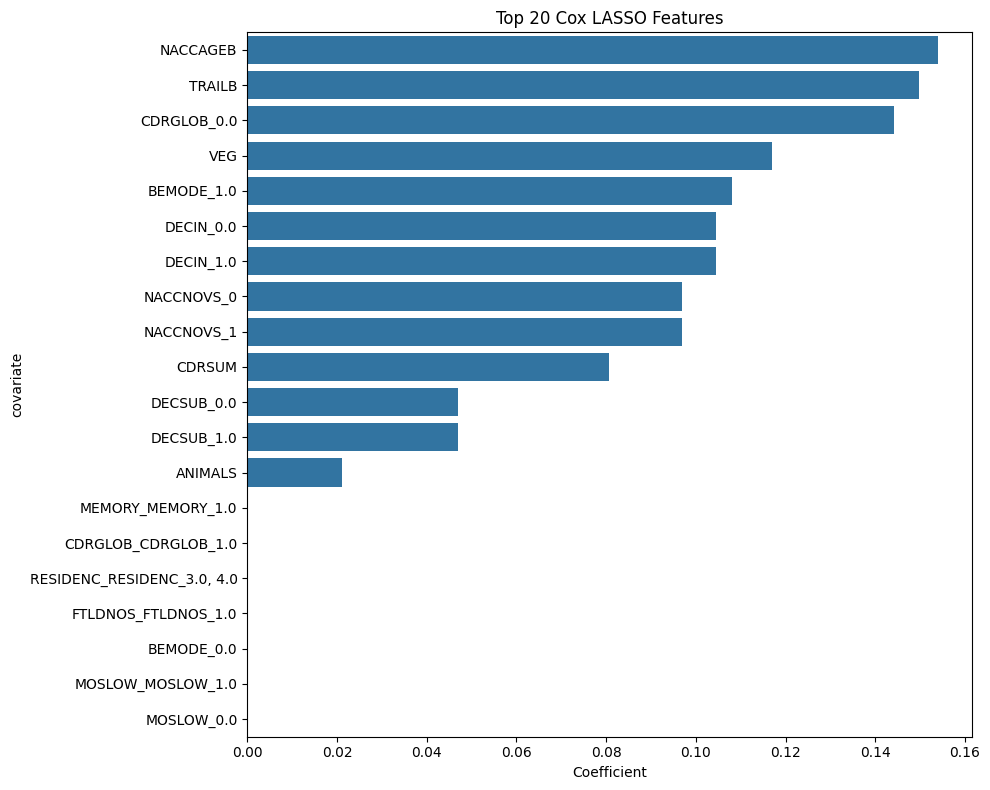

In [ ]:
top20 = lasso_all_features.head(20).abs()

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    x=top20["coef"],
    y=top20.index,
    ax=ax,
)
ax.set_xlabel("Coefficient")
ax.set_title("Top 20 Cox LASSO Features")
plt.tight_layout()
plt.show()

## Analyse feature selected features + common features

In [ ]:
features = lasso_top_features_decoded.union(vimp_top_features_decoded).union(common_features)
len(features)

NameError: name 'vimp_top_features_decoded' is not defined

### Distributions

In [ ]:
def divide_into_categorical_and_continuous(features, categorical_columns):
    categorical = []
    continuous = []
    for f in features:
        if f in categorical_columns:
            categorical.append(f)   
        else:
            continuous.append(f)
    return categorical, continuous

def draw_distributions(df, features, categorical_columns):
    categorical_features, continuous_features = divide_into_categorical_and_continuous(features, categorical_columns)
    
    # Plot categorical features first
    if categorical_features:
        n_cols = 4
        n_rows = math.ceil(len(categorical_features) / n_cols)
        _, axes1 = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 6))
        
        if n_rows == 1 and n_cols == 1:
            axes1 = np.array([axes1])
        axes1 = axes1.flatten()
        
        for i, feature in enumerate(categorical_features):
            ax = axes1[i]
            column_data = df[feature].copy().dropna()
            
            value_counts = column_data.value_counts(sort=False)
            sorted_idx = sorted(value_counts.index, key=lambda x: str(x))
            value_counts = value_counts.reindex(sorted_idx)
            bars = ax.bar(value_counts.index.astype(str), value_counts.values)
            ax.set_title(f'Distribution of {feature}')
            ax.set_xlabel(feature)
            ax.set_ylabel('Count')
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', rotation=-45)

            ax.bar_label(bars, padding=3, fontsize=8)
        
        for j in range(i + 1, len(axes1)):
            axes1[j].set_visible(False)
        
        plt.tight_layout()
        plt.suptitle('Categorical Variables Distribution', y=1.02)
        plt.show()
    
    # Plot continuous features
    if continuous_features:
        n_cols = 4
        n_rows = math.ceil(len(continuous_features) / n_cols)
        _, axes2 = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
        
        if n_rows == 1 and n_cols == 1:
            axes2 = np.array([axes2])
        axes2 = axes2.flatten()
        
        for i, feature in enumerate(continuous_features):
            ax = axes2[i]
            column_data = pd.to_numeric(df[feature].copy(), errors='coerce').dropna()
            if column_data.empty:
                ax.set_visible(False)
                continue
            
            sns.histplot(column_data, kde=True, ax=ax)
            ax.set_title(f'Distribution of {feature}')
            ax.set_xlabel(feature)
            ax.set_ylabel('Frequency')
        
        for j in range(i + 1, len(axes2)):
            axes2[j].set_visible(False)
        
        plt.tight_layout()
        plt.suptitle('Continuous Variables Distribution', y=1.02)
        plt.show()
    return categorical_features, continuous_features

In [ ]:
nacc_prepared.columns.to_list()

In [ ]:
categorical_features, continuous_features = draw_distributions(nacc_prepared, features, categorical_columns=nacc_categorical_columns)

### Assumptions

In [ ]:
def asses_hazard_assumptions(df):
  cph = CoxPHFitter(penalizer=0.05, l1_ratio=0.01)
  cph.fit(df, duration_col='TIME', event_col='EVENT_MCI')
  cph.check_assumptions(df, p_value_threshold=0.05, show_plots=False)

In [ ]:
asses_hazard_assumptions(nacc_final_eda)

### KM curves

In [ ]:
def plot_km_grid(df, strat_features, categorical_columns, time_col='TIME', event_col='EVENT_MCI', cols=3):
    strat_features = [f for f in strat_features if f in df.columns and f in categorical_columns]
    rows = (len(strat_features) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = axes.flatten() if rows > 1 else [axes]
    
    for idx, feature in enumerate(strat_features):
        for name, group in df.groupby(feature):
            kmf = KaplanMeierFitter().fit(group[time_col], group[event_col], label=name)
            kmf.plot_survival_function(ax=axes[idx])
        axes[idx].set_title(f'KM by {feature}')
        axes[idx].set_xlabel('Time')
        axes[idx].set_ylabel('Survival Probability')
        axes[idx].grid()
    
    for idx in range(len(strat_features), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

In [ ]:
plot_km_grid(nacc_prepared, strat_features=features, categorical_columns=nacc_categorical_columns)